In [1]:
import pandas as pd
from datasets import Dataset 
from transformers import AutoTokenizer
import numpy  as np

In [2]:
data = pd.read_csv("../data/DrugComb/DrugComb_tem_full.csv")

/tmp/ipykernel_11987/2665583074.py:1: DtypeWarning: Columns (23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/DrugComb/DrugComb_tem_full.csv")


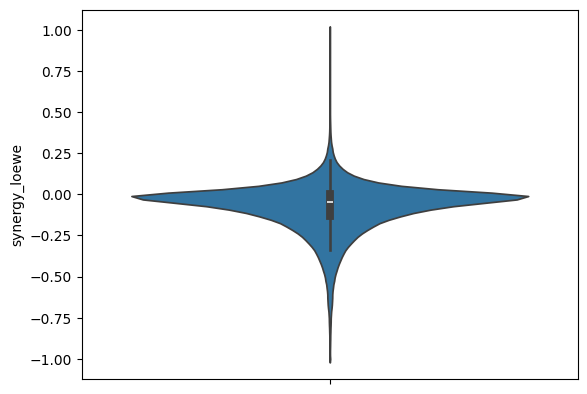

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 绘制小提琴图
#data["synergy_zip"] = np.clip(data["synergy_zip"], -100, 100)/100
sns.violinplot(data=data["synergy_loewe"])
# 显示图形
plt.show()

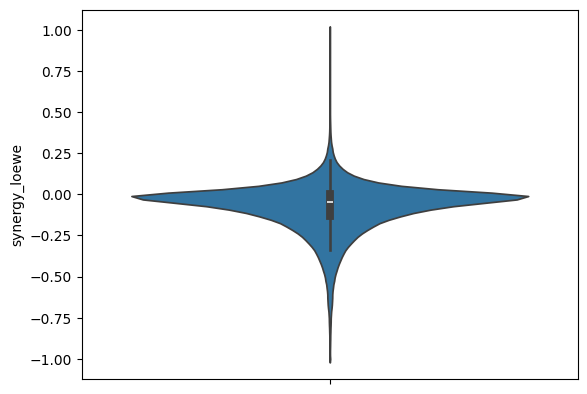

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 绘制小提琴图
#data["synergy_loewe"] = np.clip(data["synergy_zip"], -100, 100)/100
sns.violinplot(data=data["synergy_loewe"])
# 显示图形
plt.show()

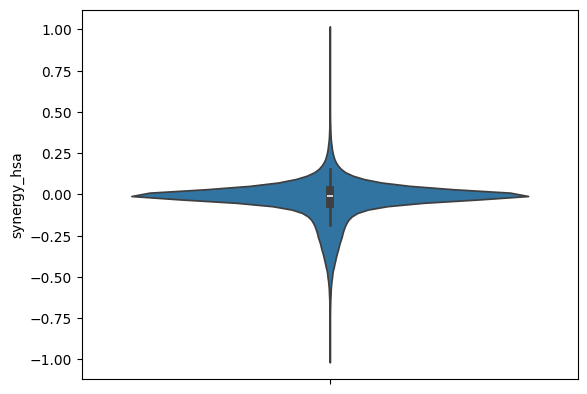

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 绘制小提琴图
#data["synergy_zip"] = np.clip(data["synergy_zip"], -100, 100)/100
sns.violinplot(data=data["synergy_hsa"])
# 显示图形
plt.show()

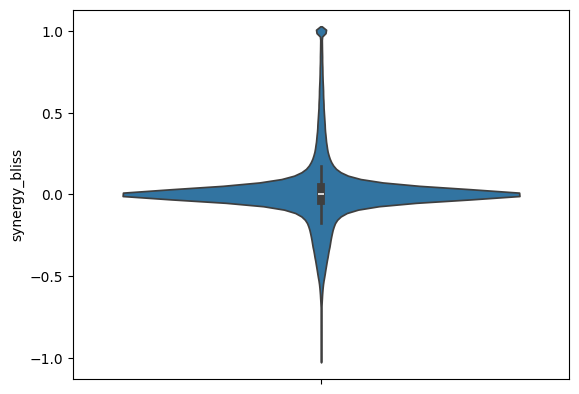

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 绘制小提琴图
#data["synergy_zip"] = np.clip(data["synergy_zip"], -100, 100)/100
sns.violinplot(data=data["synergy_bliss"])
# 显示图形
plt.show()

In [7]:
drug_f_dir = '../data/DrugComb/Process/cid_features_Roberta.pkl'
kegg_dir = "../data/DrugComb/Process/DepMap_kegg.csv"
gene_dir = "../data/DrugComb/Process/MOCO_feature_Depmap_ProteinCodingGene.pkl"
protein_dir = "../data/DrugComb/Process/TCPA_CCLE_RPPA500.tsv"
meta_dir = "../data/DrugComb/Process/Metabolomics_subsetted.csv"
model_dir = "../data/DrugComb/Process/Model.csv"
geneEffect_dir = "../data/DrugComb/Process/MOCO_feature_Depmap_geneEffect.pkl"
ssGSEA_dir = "../data/DrugComb/Process/MOCO_feature_Depmap_ssGSEA.pkl"
geneDependency_dir = "../data/DrugComb/Process/MOCO_feature_Depmap_geneDependency.pkl"
methylation_dir = "../data/DrugComb/Process/MOCO_feature_Depmap_methylation.pkl"
CNV_dir = "../data/DrugComb/Process/MOCO_feature_Depmap_CNV.pkl"
mutation_dir = "../data/DrugComb/Process/Depmap_mutation_top_var_256.pkl"

cids_dir = "../data/DrugComb/Process/DrugComb_all_witch_CID_data_name2_CID_dict.pkl"

In [8]:
kegg = pd.read_csv(kegg_dir,index_col=0,header=0)
protein = pd.read_table(protein_dir,sep='\t',index_col=0,header=0)
gene = pd.read_pickle(gene_dir)
pc_ls = [i.split("_")[0] for i in protein.index.to_list()]
protein.index = pc_ls
#c_ls = [i.replace("-","") for i in gene.index.to_list()]
#gene.index = c_ls

meta = pd.read_csv(meta_dir,index_col=0)
cell_model = pd.read_csv(model_dir,index_col=0)
ssGSEA = pd.read_pickle(ssGSEA_dir)
geneEffect = pd.read_pickle(geneEffect_dir)
geneDependency = pd.read_pickle(geneDependency_dir)
methylation = pd.read_pickle(methylation_dir)
CNV = pd.read_pickle(CNV_dir)
mutation = pd.read_pickle(mutation_dir)

In [9]:
# 定义替换规则
index_replacement_rules = {
    'COLO699': 'CHL1DM',
    'D341MED': 'D341Med'
}

protein = protein.rename(index=index_replacement_rules)

In [10]:
tran0 = data[data["group"].isin([0,6])]
tran1 = data[data["group"].isin([1])]
tran2 = data[data["group"].isin([2])]
tran3 = data[data["group"].isin([3])]
tran4 = data[data["group"].isin([4])]

In [11]:
cell_ls = set(data["cell_line_name"].tolist()) & set(kegg.columns.tolist())

select_col = ['drug_row', 'drug_col', 'cell_line_name','synergy_zip','synergy_loewe','synergy_hsa', 'synergy_bliss']

tran10 = tran0[select_col]
tran11 = tran1[select_col]
tran12 = tran2[select_col]
tran13 = tran3[select_col]
tran14 = tran4[select_col]


del tran0,tran1,tran2,tran3,tran4

In [12]:
#sampled_df['synergy_loewe'] = pd.to_numeric(sampled_df['synergy_loewe'], errors='coerce')
tran10['synergy_zip'] = pd.to_numeric(tran10['synergy_zip'], errors='coerce')
tran11['synergy_zip'] = pd.to_numeric(tran11['synergy_zip'], errors='coerce')
tran12['synergy_zip'] = pd.to_numeric(tran12['synergy_zip'], errors='coerce')
tran13['synergy_zip'] = pd.to_numeric(tran13['synergy_zip'], errors='coerce')
tran14['synergy_zip'] = pd.to_numeric(tran14['synergy_zip'], errors='coerce')

#sampled_df['synergy_loewe'] = pd.to_numeric(sampled_df['synergy_loewe'], errors='coerce')
tran10['synergy_loewe'] = pd.to_numeric(tran10['synergy_loewe'], errors='coerce')
tran11['synergy_loewe'] = pd.to_numeric(tran11['synergy_loewe'], errors='coerce')
tran12['synergy_loewe'] = pd.to_numeric(tran12['synergy_loewe'], errors='coerce')
tran13['synergy_loewe'] = pd.to_numeric(tran13['synergy_loewe'], errors='coerce')
tran14['synergy_loewe'] = pd.to_numeric(tran14['synergy_loewe'], errors='coerce')

#sampled_df['synergy_loewe'] = pd.to_numeric(sampled_df['synergy_loewe'], errors='coerce')
tran10['synergy_hsa'] = pd.to_numeric(tran10['synergy_hsa'], errors='coerce')
tran11['synergy_hsa'] = pd.to_numeric(tran11['synergy_hsa'], errors='coerce')
tran12['synergy_hsa'] = pd.to_numeric(tran12['synergy_hsa'], errors='coerce')
tran13['synergy_hsa'] = pd.to_numeric(tran13['synergy_hsa'], errors='coerce')
tran14['synergy_hsa'] = pd.to_numeric(tran14['synergy_hsa'], errors='coerce')

#sampled_df['synergy_loewe'] = pd.to_numeric(sampled_df['synergy_loewe'], errors='coerce')
tran10['synergy_bliss'] = pd.to_numeric(tran10['synergy_bliss'], errors='coerce')
tran11['synergy_bliss'] = pd.to_numeric(tran11['synergy_bliss'], errors='coerce')
tran12['synergy_bliss'] = pd.to_numeric(tran12['synergy_bliss'], errors='coerce')
tran13['synergy_bliss'] = pd.to_numeric(tran13['synergy_bliss'], errors='coerce')
tran14['synergy_bliss'] = pd.to_numeric(tran14['synergy_bliss'], errors='coerce')

In [13]:
tran_data0 = Dataset.from_pandas(tran10)
tran_data1 = Dataset.from_pandas(tran11)
tran_data2 = Dataset.from_pandas(tran12)
tran_data3 = Dataset.from_pandas(tran13)
tran_data4 = Dataset.from_pandas(tran14)

In [14]:
drug_cids = pd.read_pickle(cids_dir)
drug_f = pd.read_pickle(drug_f_dir)
geneT = gene.T
metaT = meta.T
proteinT = protein.T
keggT = kegg.T
geneEffectT = geneEffect.T
ssGSEAT = ssGSEA.T
geneDependencyT = geneDependency.T
methylationT = methylation.T
CNVT = CNV.T
mutationT = mutation.T

model_cell_name_ls = cell_model["StrippedCellLineName"].unique().tolist()
import torch


no_in_gene = []
no_in_meta = []
no_in_kegg = []
no_in_protein = []
no_in_geneEffect = []
no_in_ssGSEA = []
no_in_geneDependency = []
no_in_methylation = []
no_in_CNV = []
no_in_mutation = []
def pro_data(data):
    data["drug_f1"] = drug_f[drug_cids[data['drug_row']]]
    data["cid_1"] = drug_cids[data['drug_row']]
    data["drug_f2"] = drug_f[drug_cids[data['drug_col']]]
    data["cid_2"] = drug_cids[data['drug_col']]
    cell_name = data['cell_line_name']
    if cell_name in model_cell_name_ls:
        cl_id = cell_model[cell_model["StrippedCellLineName"]==cell_name].index.tolist()[0]
    else:
        cl_id = None
    if cl_id in metaT.columns.tolist():
        data["meta_f"] = metaT[cl_id]
    else:
        no_in_meta.append(cell_name)
        data["meta_f"] = metaT.mean(axis=1)
    if cl_id in kegg.columns.tolist():
        data["kegg_f"] = kegg[cl_id]
    else:
        no_in_kegg.append(cell_name)
        data["kegg_f"] = kegg.mean(axis=1)
    if cl_id in geneT.columns.tolist():
        data["gene_f"] = geneT[cl_id]
    else:
        no_in_gene.append(cell_name)
        data["gene_f"] = geneT.mean(axis=1)
    
    if cell_name in proteinT.columns.tolist():
        data["protein_f"] = proteinT[cell_name]
    else:
        no_in_protein.append(cell_name)
        data["protein_f"] = proteinT.mean(axis=1)
    if cl_id in geneEffectT.columns.tolist():
        data["geneEffect_f"] = geneEffectT[cl_id]
    else:
        no_in_geneEffect.append(cell_name)
        data["geneEffect_f"] = geneEffectT.mean(axis=1)
    if cl_id in ssGSEAT.columns.tolist():
        data["ssGSEA_f"] = ssGSEAT[cl_id]
    else:
        no_in_ssGSEA.append(cell_name)
        data["ssGSEA_f"] = ssGSEAT.mean(axis=1)
    if cl_id in geneDependencyT.columns.tolist():
        data["geneDependency_f"] = geneDependencyT[cl_id]
    else:
        no_in_geneDependency.append(cell_name)
        data["geneDependency_f"] = geneDependencyT.mean(axis=1)
    if cl_id in methylationT.columns.tolist():
        data["methylation_f"] = methylationT[cl_id]
    else:
        no_in_methylation.append(cell_name)
        data["methylation_f"] = methylationT.mean(axis=1)
    if cl_id in CNVT.columns.tolist():
        data["CNV_f"] = CNVT[cl_id]
    else:
        no_in_CNV.append(cell_name)
        data["CNV_f"] = CNVT.mean(axis=1)
    if cl_id in mutationT.columns.tolist():
        data["mutation_f"] = mutationT[cl_id]
    else:
        no_in_mutation.append(cell_name)
        data["mutation_f"] = mutationT.mean(axis=1)
    data["zip"] = data["synergy_zip"]
    data["loewe"] = data["synergy_loewe"]
    data["hsa"] = data["synergy_hsa"]
    data["bliss"] = data["synergy_bliss"]
    return data

In [15]:

tokenized_train0 = tran_data0.map(pro_data)
tokenized_train1 = tran_data1.map(pro_data)
tokenized_train2 = tran_data2.map(pro_data)
tokenized_train3 = tran_data3.map(pro_data)
tokenized_train4 = tran_data4.map(pro_data)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [16]:
import torch
import torch.nn.functional as F
import pandas as pd

from torch.utils.data import Dataset, DataLoader
import torch
import ast
import torch
import torch.nn.functional as F

# 2. 优化 Dataset 类
class mydata1(Dataset):
    def __init__(self, data):
        self.data = data
        # 预处理数据
        self._preprocess_data()
        
    def _preprocess_data(self):
        # 提前将数据转换为张量并移到CPU内存
        self.processed_data = []
        for item in self.data:
            processed_item = {
                "drug_f1": torch.as_tensor(item['drug_f1'], dtype=torch.float32),
                "drug_f2": torch.as_tensor(item['drug_f2'], dtype=torch.float32),
                #"molt5_f1": torch.as_tensor(item['molt5_f1'], dtype=torch.float32),
                #"molt5_f2": torch.as_tensor(item['molt5_f2'], dtype=torch.float32),
                "gene_f": torch.as_tensor(item['gene_f'], dtype=torch.float32),
                "protein_f": torch.as_tensor(item['protein_f'], dtype=torch.float32),
                "kegg_f": torch.as_tensor(item['kegg_f'], dtype=torch.float32),
                "meta_f": torch.as_tensor(item['meta_f'], dtype=torch.float32),
                "zip": torch.as_tensor([item['zip']], dtype=torch.float32),
                "loewe": torch.as_tensor([item['loewe']], dtype=torch.float32),
                "hsa": torch.as_tensor([item['hsa']], dtype=torch.float32),
                "bliss": torch.as_tensor([item['bliss']], dtype=torch.float32),
                "geneEffect_f": torch.as_tensor(item['geneEffect_f'], dtype=torch.float32),
                "ssGSEA_f": torch.as_tensor(item['ssGSEA_f'], dtype=torch.float32),
                "geneDependency_f": torch.as_tensor(item['geneDependency_f'], dtype=torch.float32),
                "methylation_f": torch.as_tensor(item['methylation_f'], dtype=torch.float32),
                "CNV_f": torch.as_tensor(item['CNV_f'], dtype=torch.float32),
                "mutation_f": torch.as_tensor(item['mutation_f'], dtype=torch.float32),
                "cell": [item['cell_line_name']],
                "cid_1": [item['cid_1']],
                "cid_2": [item['cid_2']],
                #"HSA": torch.as_tensor([item['synergy'][0]], dtype=torch.float32)
            }
            self.processed_data.append(processed_item)

    def __len__(self):
        return len(self.processed_data)
    
    def __getitem__(self, index):
        return self.processed_data[index]

In [17]:
train_dataloader0 = mydata1(data=tokenized_train0)
torch.save(train_dataloader0, '../data/DrugComb/drugcomb_fold_0_data_demo.pt')
train_dataloader1 = mydata1(data=tokenized_train1)
torch.save(train_dataloader1, '../data/DrugComb/drugcomb_fold_1_data_demo.pt')
train_dataloader2 = mydata1(data=tokenized_train2)
torch.save(train_dataloader2, '../data/DrugComb/drugcomb_fold_2_data_demo.pt')
train_dataloader3 = mydata1(data=tokenized_train3)
torch.save(train_dataloader3, '../data/DrugComb/drugcomb_fold_3_data_demo.pt')
train_dataloader4 = mydata1(data=tokenized_train4)
torch.save(train_dataloader4, '../data/DrugComb/drugcomb_fold_4_data_demo.pt')